# Capstone Session 6

This notebook is generated from the copied `Capstone_Session_6.pdf` directions and the staged `adultcensusincome.csv` dataset.

## Objective

Build and compare classification models for Adult Census income prediction while preserving the PDF-ordered exploratory, preprocessing, imbalance, and evaluation flow.

In [ ]:
from pathlib import Path
import json
import sys
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

IS_COLAB = 'google.colab' in sys.modules
GITHUB_REPO_OWNER = 'FrancisBurnet'
GITHUB_REPO_NAME = 'francisburnet'
GITHUB_REPO_BRANCH = 'main'
CAPSTONE_ROOT = Path('Incremental Capstones/Machine Learning Using Python/Capstone Session 6')
DATASET_FILENAME = 'adultcensusincome.csv'


def build_raw_github_url(relative_path: Path) -> str:
    encoded_path = quote(relative_path.as_posix(), safe='/')
    return (
        f"https://raw.githubusercontent.com/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}/"
        f"{GITHUB_REPO_BRANCH}/{encoded_path}"
    )


def resolve_capstone_dir() -> Path | None:
    current = Path.cwd().resolve()
    capstone_parts = CAPSTONE_ROOT.parts
    for candidate in [current, *current.parents]:
        if len(candidate.parts) >= len(capstone_parts) and candidate.parts[-len(capstone_parts):] == capstone_parts:
            return candidate
        nested_candidate = candidate / CAPSTONE_ROOT
        if nested_candidate.exists():
            return nested_candidate
    return None


CAPSTONE_DIR = resolve_capstone_dir()
DATASET_URL = build_raw_github_url(CAPSTONE_ROOT / DATASET_FILENAME)

if CAPSTONE_DIR is not None:
    OUTPUT_ROOT = CAPSTONE_DIR
    OUTPUT_MODE = 'permanent capstone outputs'
    OUTPUT_DISPLAY = (CAPSTONE_ROOT / 'outputs').as_posix()
else:
    runtime_root = Path('/content/capstone-session-6-runtime') if IS_COLAB else Path.cwd().resolve() / 'capstone-session-6-runtime'
    OUTPUT_ROOT = runtime_root
    OUTPUT_MODE = 'runtime scratch outputs; export final artifacts back into the capstone outputs folder'
    OUTPUT_DISPLAY = 'capstone-session-6-runtime/outputs'

OUTPUTS_DIR = (OUTPUT_ROOT / 'outputs').resolve()
PLOTS_DIR = OUTPUTS_DIR / 'plots'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

print('Runtime:', 'Google Colab' if IS_COLAB else 'Notebook runtime')
print('Capstone artifact path:', CAPSTONE_ROOT.as_posix())
print('Dataset source:', DATASET_URL)
print('Output mode:', OUTPUT_MODE)
print('Output target:', OUTPUT_DISPLAY)

In [ ]:
df = pd.read_csv(DATASET_URL)
display(df.head())
print('Dataset source used:', DATASET_URL)
print('Shape:', df.shape)
object_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
question_mark_counts = {column: int((df[column].astype(str).str.strip() == '?').sum()) for column in object_columns}
print('Question mark counts:', question_mark_counts)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K


Shape: (32561, 14)
Question mark counts: {'workclass': 1836, 'education': 0, 'marital.status': 0, 'occupation': 1843, 'relationship': 0, 'sex': 0, 'native.country': 583, 'income': 0}


In [3]:
df = df.replace(' ?', np.nan).replace('?', np.nan)
for column in object_columns:
    if df[column].isna().any():
        df[column] = df[column].fillna(df[column].mode().iloc[0])
for column in df.columns:
    if df[column].isna().any():
        df[column] = df[column].fillna(df[column].median())
print('Remaining null values:', int(df.isna().sum().sum()))

Remaining null values: 0


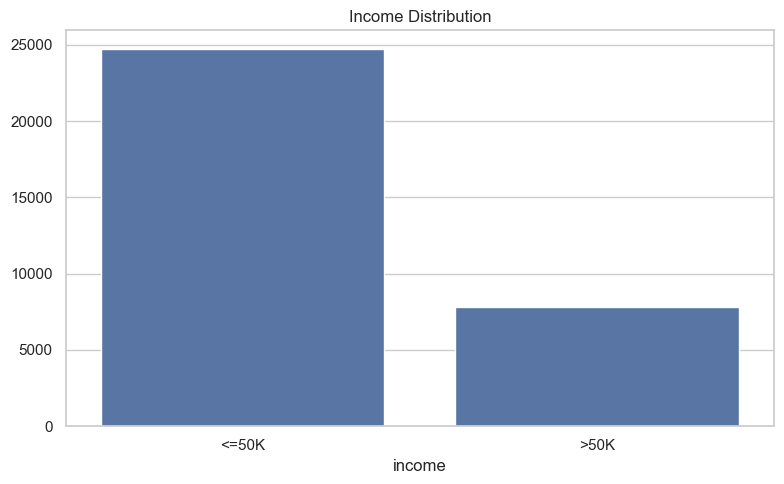

{'class_counts': {'<=50K': 24720, '>50K': 7841}, 'minority_ratio': 0.3172}

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
income_counts = df['income'].value_counts()
sns.barplot(x=income_counts.index, y=income_counts.values, ax=ax)
ax.set_title('Income Distribution')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'income_barplot.png', dpi=150)
plt.show()
plt.close(fig)
balance_summary = {
    'class_counts': income_counts.to_dict(),
    'minority_ratio': round(float(income_counts.min() / income_counts.max()), 4),
}
balance_summary

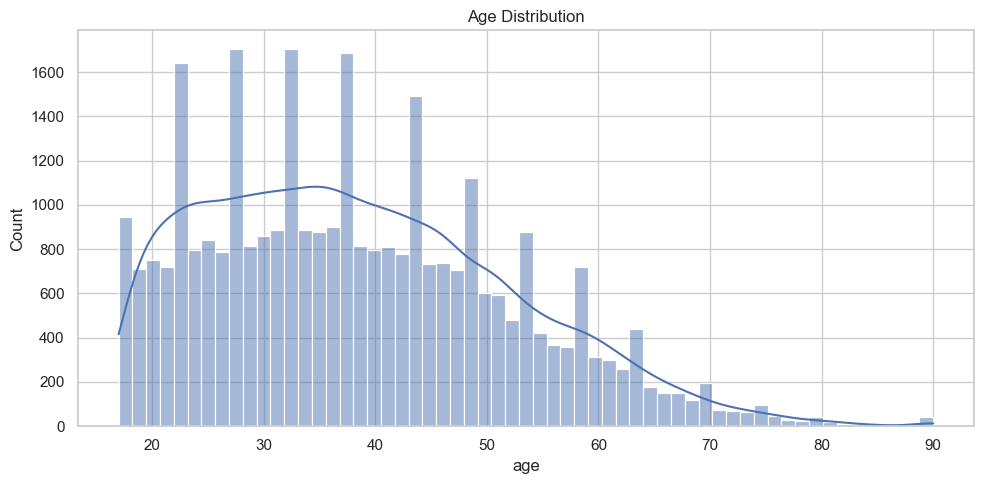

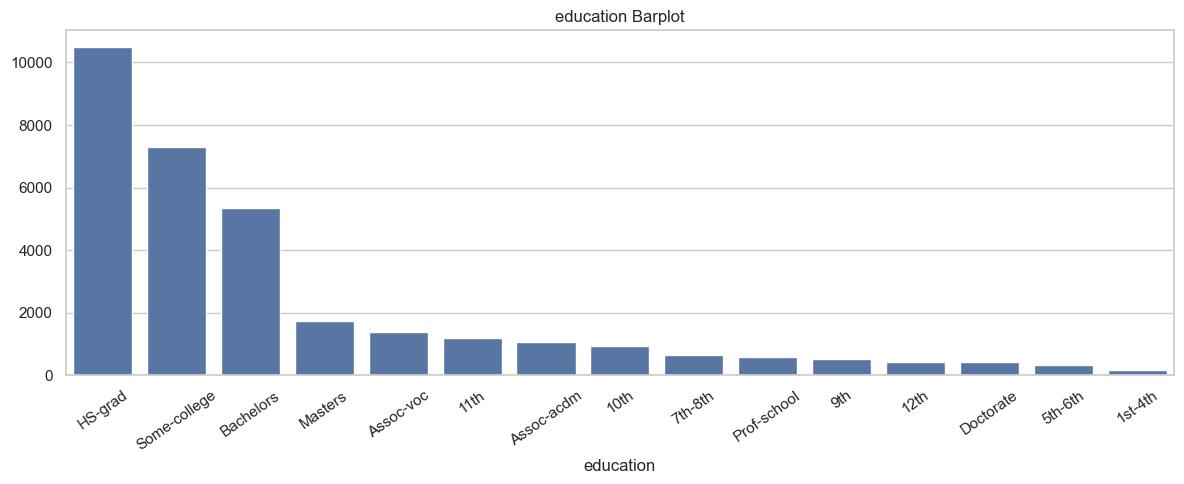

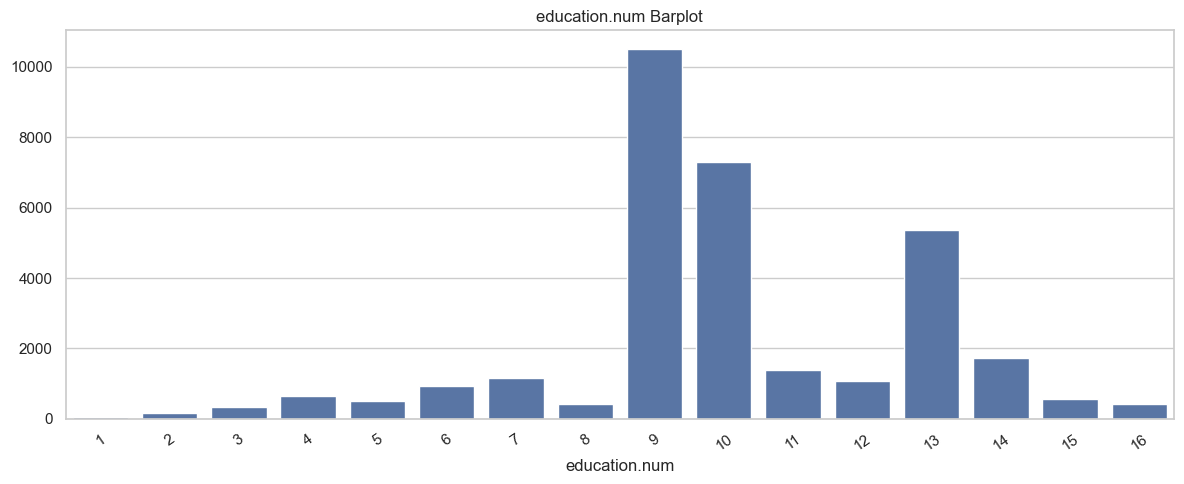

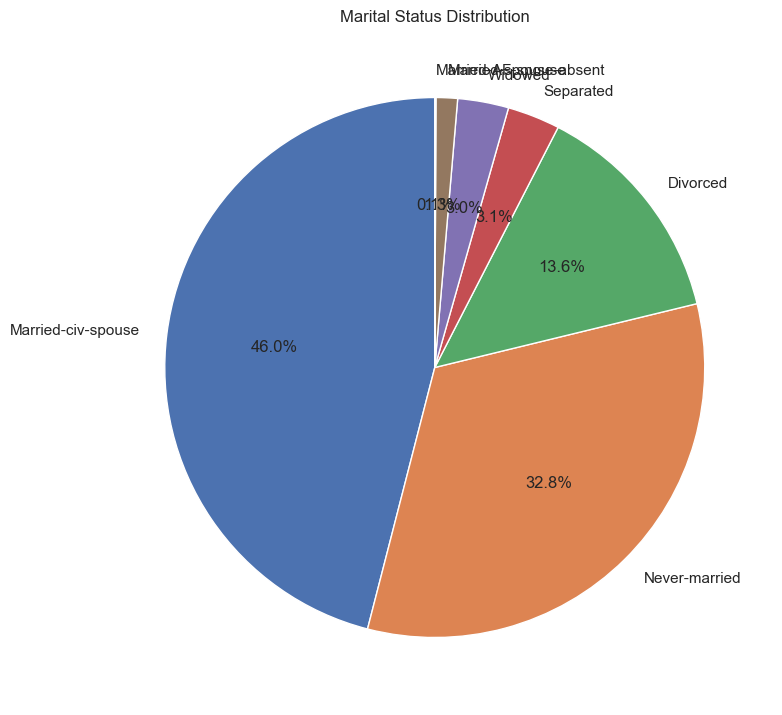

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['age'], kde=True, ax=ax)
ax.set_title('Age Distribution')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'age_distribution.png', dpi=150)
plt.show()
plt.close(fig)

for column in ['education', 'education.num']:
    fig, ax = plt.subplots(figsize=(12, 5))
    counts = df[column].value_counts().sort_values(ascending=False).head(15) if column == 'education' else df[column].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    ax.set_title(f'{column} Barplot')
    ax.tick_params(axis='x', rotation=35)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f'{column.replace('.', '_')}_barplot.png', dpi=150)
    plt.show()
    plt.close(fig)

marital_counts = df['marital.status'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(marital_counts.values, labels=marital_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Marital Status Distribution')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'marital_status_pie.png', dpi=150)
plt.show()
plt.close(fig)

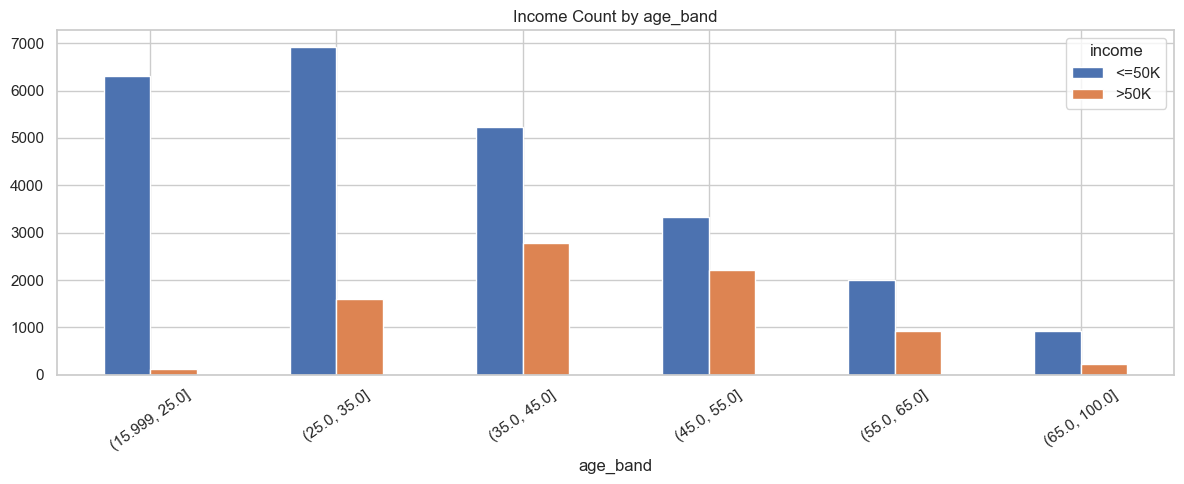

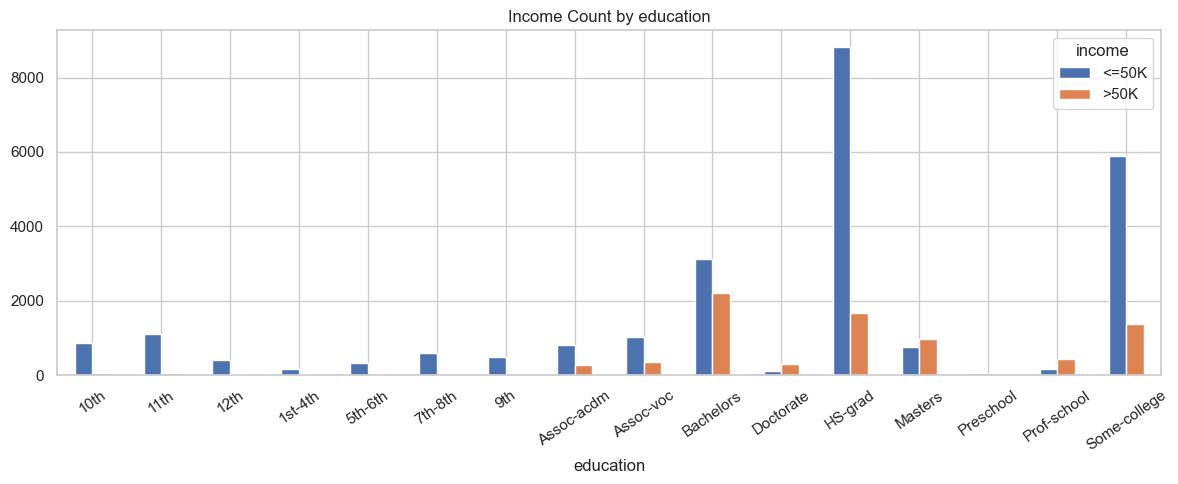

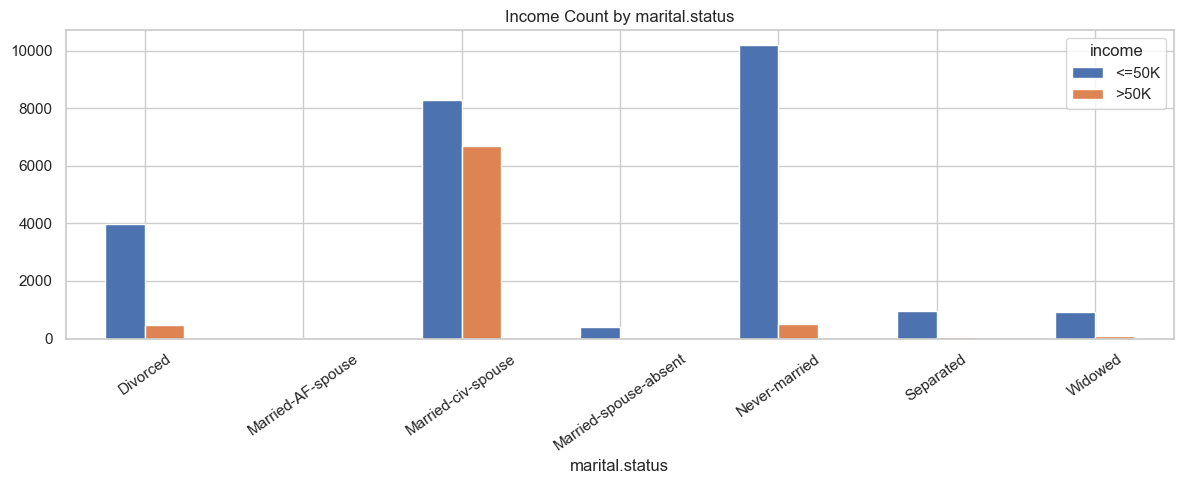

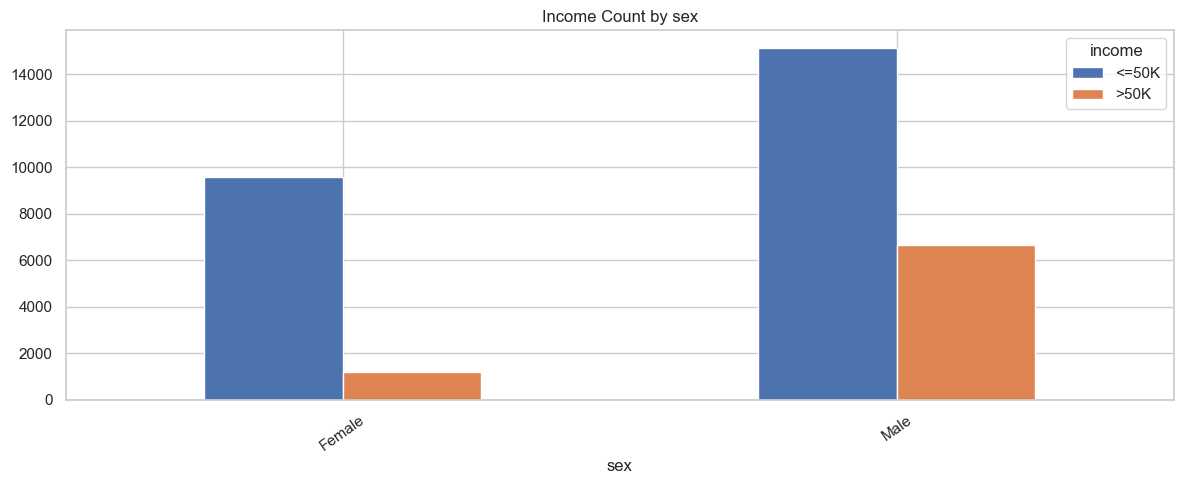

In [6]:
df['age_band'] = pd.cut(df['age'], bins=[16, 25, 35, 45, 55, 65, 100], include_lowest=True)
for column in ['age_band', 'education', 'marital.status', 'sex']:
    fig, ax = plt.subplots(figsize=(12, 5))
    grouped = pd.crosstab(df[column], df['income'])
    grouped.plot(kind='bar', stacked=False, ax=ax)
    ax.set_title(f'Income Count by {column}')
    ax.tick_params(axis='x', rotation=35)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f'income_by_{str(column).replace('.', '_')}.png', dpi=150)
    plt.show()
    plt.close(fig)

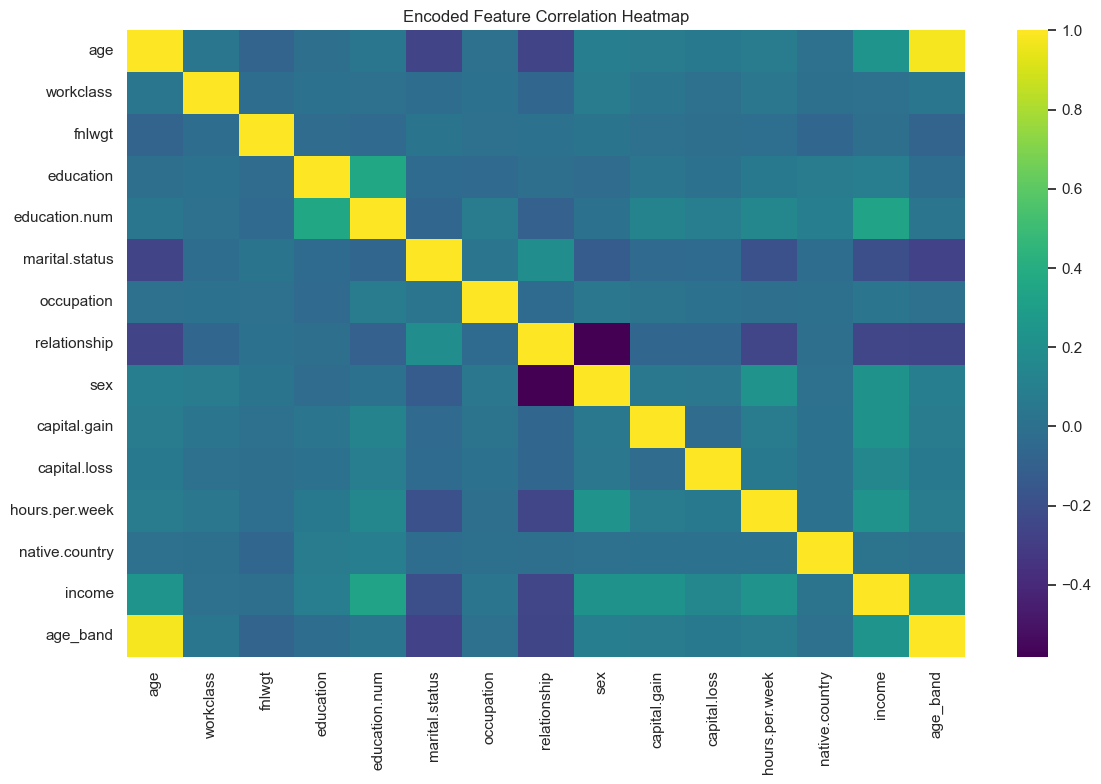

{'income': 1.0,
 'education.num': 0.335153952690943,
 'age_band': 0.23638023840533365,
 'age': 0.234037102648859,
 'hours.per.week': 0.22968906567080932,
 'capital.gain': 0.22332881819538292,
 'sex': 0.21598015058403752,
 'capital.loss': 0.15052631177035683,
 'education': 0.07931660927729825,
 'occupation': 0.03462453745149705,
 'native.country': 0.02305804502812131,
 'workclass': 0.0026929737847155824,
 'fnlwgt': -0.009462557247529214,
 'marital.status': -0.19930700917197833,
 'relationship': -0.25091814171775123}

In [7]:
encoded_df = df.copy()
label_encoders = {}
for column in encoded_df.select_dtypes(include=['object', 'string', 'category']).columns:
    encoder = LabelEncoder()
    encoded_df[column] = encoder.fit_transform(encoded_df[column].astype(str))
    label_encoders[column] = encoder

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(encoded_df.corr(numeric_only=True), cmap='viridis', ax=ax)
ax.set_title('Encoded Feature Correlation Heatmap')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()
plt.close(fig)
correlation_to_income = encoded_df.corr(numeric_only=True)['income'].sort_values(ascending=False).to_dict()
correlation_to_income

In [8]:
X = encoded_df.drop(columns=['income'])
y = encoded_df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
sampler = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_scaled, y_train)
print('Balanced train distribution:', pd.Series(y_train_balanced).value_counts().to_dict())

Balanced train distribution: {1: 19775, 0: 19775}


In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN Classifier': KNeighborsClassifier(),
    'SVM Classifier': SVC(),
    'Naive Bayes Classifier': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42, n_estimators=200),
}
results = []
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    predictions = model.predict(X_test_scaled)
    results.append({
        'model': name,
        'accuracy': float(accuracy_score(y_test, predictions)),
        'f1_score': float(f1_score(y_test, predictions)),
    })
results_df = pd.DataFrame(results).sort_values(['f1_score', 'accuracy'], ascending=False).reset_index(drop=True)
display(results_df)
best_model = results_df.iloc[0].to_dict()
best_model

,model,accuracy,f1_score
0,Random Forest Classifier,0.849532,0.688889
1,SVM Classifier,0.793951,0.665002
2,KNN Classifier,0.777675,0.627955
3,Logistic Regression,0.775986,0.621334
4,Decision Tree Classifier,0.809458,0.600064
5,Naive Bayes Classifier,0.817442,0.567794


{'model': 'Random Forest Classifier',
 'accuracy': 0.849531705819131,
 'f1_score': 0.6888888888888889}

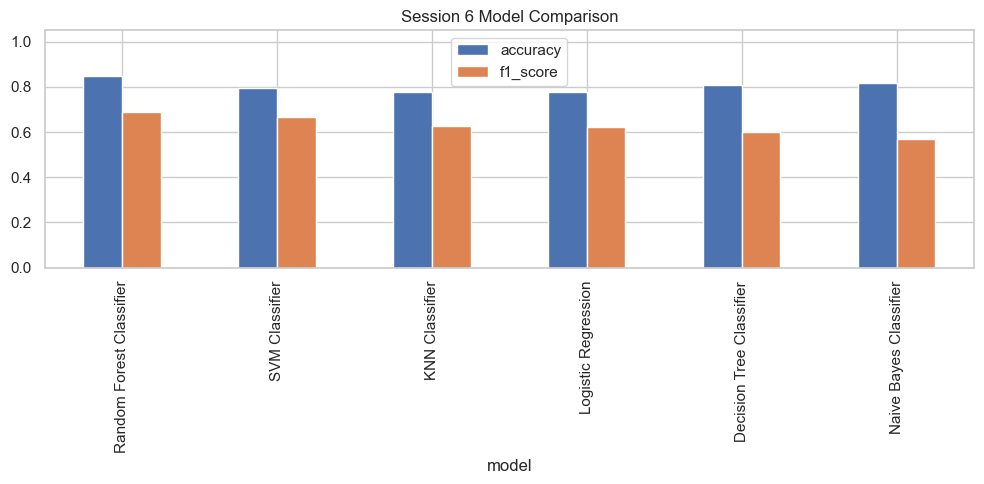

{'dataset_shape': [32561, 15],
 'question_mark_counts_before_cleaning': {'workclass': 1836,
  'education': 0,
  'marital.status': 0,
  'occupation': 1843,
  'relationship': 0,
  'sex': 0,
  'native.country': 583,
  'income': 0},
 'balance_summary': {'class_counts': {'<=50K': 24720, '>50K': 7841},
  'minority_ratio': 0.3172},
 'balanced_train_distribution': {1: 19775, 0: 19775},
 'correlation_to_income': {'income': 1.0,
  'education.num': 0.335153952690943,
  'age_band': 0.23638023840533365,
  'age': 0.234037102648859,
  'hours.per.week': 0.22968906567080932,
  'capital.gain': 0.22332881819538292,
  'sex': 0.21598015058403752,
  'capital.loss': 0.15052631177035683,
  'education': 0.07931660927729825,
  'occupation': 0.03462453745149705,
  'native.country': 0.02305804502812131,
  'workclass': 0.0026929737847155824,
  'fnlwgt': -0.009462557247529214,
  'marital.status': -0.19930700917197833,
  'relationship': -0.25091814171775123},
 'model_results': [{'model': 'Logistic Regression',
   'a

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(x='model', y=['accuracy', 'f1_score'], kind='bar', ax=ax)
ax.set_title('Session 6 Model Comparison')
ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'model_comparison.png', dpi=150)
plt.show()
plt.close(fig)
results_df.to_csv(OUTPUTS_DIR / 'session_6_model_metrics.csv', index=False)
summary = {
    'dataset_shape': list(df.shape),
    'question_mark_counts_before_cleaning': question_mark_counts,
    'balance_summary': balance_summary,
    'balanced_train_distribution': pd.Series(y_train_balanced).value_counts().to_dict(),
    'correlation_to_income': correlation_to_income,
    'model_results': results,
    'best_model': best_model,
    'notes': [
        'RandomOverSampler is used as the explicit imbalance-fix technique from the PDF options.',
        'The split is stratified to preserve the original class ratio before balancing the training data.',
    ],
}
with open(OUTPUTS_DIR / 'session_6_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary